In [19]:
from dotenv import load_dotenv

load_dotenv()

True

In [20]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model = "text-embedding-3-large")

vector_store = Chroma(
    embedding_function = embedding_function,
    collection_name= "income_tax_collection",
    persist_directory= "../chroma/income_tax_collection",
)

retriever = vector_store.as_retriever(search_kwargs = {"k": 3})

In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [22]:
def retrieve(state: AgentState) -> AgentState:
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [23]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [24]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

generate_llm = ChatOpenAI(model='gpt-4o', max_completion_tokens=100)

def generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return { 'answer': response.content }

In [25]:
from langsmith import Client
from typing import Literal
client = Client()

doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance", dangerously_pull_public_prompt=True)

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'relevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    if response["Score"] == 1:
        return "relevant"
    return "irrelevant"

In [26]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

rewrite_prompt = PromptTemplate.from_template("""사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요
질문: {query}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})

    return {'query': response}


In [27]:
from langchain_community.tools import TavilySearchResults
tavily_search_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)
def web_search(state: AgentState) -> AgentState:
    query = state['query']
    results = tavily_search_tool.invoke(query)

    return {'context': results}

In [28]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [29]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'web_search'
    }
)
graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [30]:
graph = graph_builder.compile()

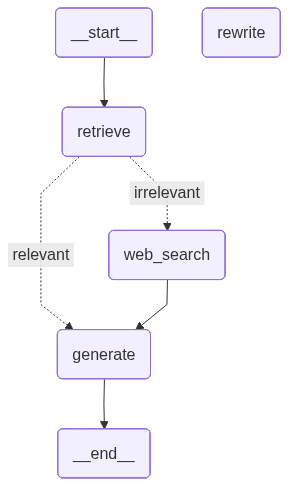

In [31]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
initial_state = {'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'context': [{'title': '연봉 5천만원 직장인의 세금이 624만원이 나오는게... - Inflearn | Community Q&A',
   'url': 'https://www.inflearn.com/community/questions/1586858/%EC%97%B0%EB%B4%89-5%EC%B2%9C%EB%A7%8C%EC%9B%90-%EC%A7%81%EC%9E%A5%EC%9D%B8%EC%9D%98-%EC%84%B8%EA%B8%88%EC%9D%B4-624%EB%A7%8C%EC%9B%90%EC%9D%B4-%EB%82%98%EC%98%A4%EB%8A%94%EA%B2%8C-%EB%A7%9E%EB%82%98%EC%9A%94?srsltid=AfmBOooz8oPp-AozzVH9eLx66k2Taclb-9gk0DQ1pM6Q0f9XseFv5OCO',
   'content': '인적공제·연금보험료공제 등 → 과세표준 산출\n\n과세표준에 소득세율표 적용\n\n산출세액에서 세액공제 (근로소득세액공제 등) 적용 → 결정세액\n\n결론적으로 제가 소득세에 대해 잘 몰라서 gpt가 말한게 할루시네이션일 수 있지만,\n\n만약 gpt처럼 실제로 근로소득금액을 산출해서 소득세를 계산하는게 맞을 경우, 강의에 있는 llm이 모두 틀린 답변을 내놓은 것 아닌가요?\n\n만약 강의처럼 연봉 5천만원의 직장인 혹은 거주자의 소득세가 표만 보고 단순 계산하여 624만원인 것이 맞을 경우, 제가 어떤 과정을 더 해야할 지 모르겠습니다.. 계속해서 근로소득공제를 계산합니다. 거주자로 쿼리를 바꿔도요.\n\nQuiz\n\nLangGraph에서 \'Conditional Edge\'의 주된 역할은 무엇일까요?\n\n두 노드를 무조건 연결하는 역할\n\n에이전트의 현재 상태를 저장하는 역할\n\n그래프가 상태나 조건에 따라 다음 노드를 동적으로 선택하게 함\n\n특정 작업을 수행하거나 액션을 실행함\n\nAnswer 2\n\

In [33]:
initial_state = {'query': '역삼역 맛집을 추천해주세요'}
graph.invoke(initial_state)

{'query': '역삼역 맛집을 추천해주세요',
 'context': [{'title': '역삼역 점심 맛집 베스트 추천 top 10',
   'url': 'https://hotel-iu.tistory.com/8573',
   'content': '|  고래불 역삼본점 바로가기▲ | [...] |  | [...] |  |',
   'score': 0.9999422,
   'raw_content': '# [초코초코 해피라이프](https://hotel-iu.tistory.com/ "초코초코 해피라이프")\n\n추천 TOP 10\n\n## 역삼역 점심 맛집 베스트 추천 top 10\n\n초코초코 코니코니 2025. 2. 27. 20:24\n\n반응형\n\n#### **역삼역 점심 맛집 베스트 추천 top 10**\n\n---\n\n역삼역 점심 맛집 베스트 추천 top 10곳을 소개합니다.\n\n---\n\n|  |\n| --- |\n| **1: 아침점심저녁 강남점** |\n|  |\n| 상호명: 아침점심저녁 강남점  주소: 서울특별시 강남구 역삼동 706-17 지하1층 B102호  전화번호: 미입력  관련 키워드: [\'제육계란이불덮밥\', \'순살닭도리탕\', \'아구도리탕\', \'불고기덮밥\', \'고등어덮밥\']  관련 태그: 미입력  영업시간: 미입력 |\n| 소개글: 몽글몽글한 계란과 어울리는 재료들의 덮밥과 집밥 생각나는 따뜻한 찌개요리들 배달과 포장을 전문으로 하고있습니다!! |\n| **<https://map.naver.com/p/entry/place/1249578375>** 아침점심저녁 강남점 바로가기▲ |\n\n---\n\n|  |\n| --- |\n| **2: 빨강우산 부대찌개 선릉역 본점 점심저녁 전문** |\n|  |\n| 상호명: 빨강우산 부대찌개 선릉역 본점 점심저녁 전문  주소: 서울특별시 강남구 역삼동 702-13 성지하이츠1 오피스텔 지하1층 107호  전화번호: 미입력  관련 키워드: [\'선릉역부대찌개\', \'강남점심식당\